In [ ]:
# 1 Import Required Libraries

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

print('Tensorflow version:', tf.__version__)


Tensorflow version: 2.19.0


# 2 Load MNIST Dataset

In [ ]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

In [ ]:
#  Understand the Dataset

print("Training data shape:", x_train.shape)
print("Testing data shape:", x_test.shape)

Training data shape: (60000, 28, 28)
Testing data shape: (10000, 28, 28)


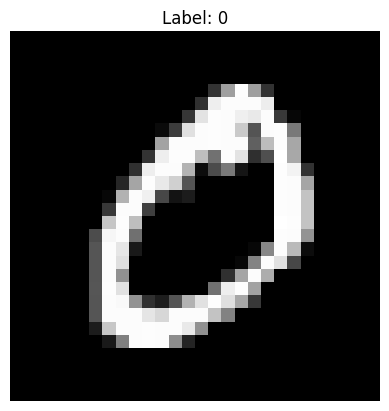

In [ ]:
# To visualize the second index datsets

plt.imshow(x_train[1], cmap='gray')
plt.title(f"Label: {y_train[1]}")
plt.axis('off')
plt.show()

# 3, Data Preprocessing

In [ ]:
# (a) Normalize Pixel Values

x_train = x_train / 255.0
x_test = x_test / 255.0


Advantages: of -1

Works even if dataset size changes

More flexible and professional

Avoids errors

```
# This is formatted as code
```



In [ ]:
#  (b) Reshape for CNN

x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)


In [ ]:
# (c) One-Hot Encode Labels

y_train = tf.keras.utils.to_categorical(y_train, 10)
y_test = tf.keras.utils.to_categorical(y_test, 10)

In [ ]:
# Final Data Check

print("x_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)

x_train shape: (60000, 28, 28, 1)
y_train shape: (60000, 10)


# 4, Build the CNN Model

In [ ]:
from tensorflow.keras import layers, models

def build_model():
    model = models.Sequential([

        # Conv Layer 1
        layers.Conv2D(
            filters=64,
            kernel_size=(3,3),
            strides=(2,2),
            padding='valid',
            activation='relu',
            input_shape=(28,28,1)
        ),

        # Conv Layer 2
        layers.Conv2D(
            filters=32,
            kernel_size=(2,2),
            strides=(1,1),
            padding='same',
            activation='relu'
        ),

        # Max Pooling
        layers.MaxPooling2D(
            pool_size=(2,2),
            strides=(1,1)
        ),

        # Dropout
        layers.Dropout(0.35),

        # Flatten
        layers.Flatten(),

        # Dense Layer
        layers.Dense(256, activation='tanh'),

        # Dropout
        layers.Dropout(0.5),

        # Output Layer
        layers.Dense(10, activation='softmax')
    ])

    return model

In [ ]:
# Verify Model Architecture

model = build_model()
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 13, 13, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 13, 13, 32)     │         8,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 12, 12, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │     1,179,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,191,338 (4.54 MB)

 Trainable params: 1,191,338 (4.54 MB)

 Non-trainable params: 0 (0.00 B)

#Compile + Train Function

model = build_model()

This ensures:

🟢 Same Starting Point

Every optimizer starts with:

Same architecture

Same random initialization

Same dataset

epochs=10
x_train, y_train

✔ Same data

✔ Same number of epochs

✔ Same loss function

“The experiment is fair because each optimizer is trained on a freshly initialized model with identical architecture, dataset, and training conditions. The only varying factor is the optimizer, allowing an unbiased comparison of their performance.”

✅ FINAL UNDERSTANDING

✔ build_model() → ensures fairness

✔ compile() → defines learning strategy

✔ fit() → performs learning

✔ Only optimizer changes → valid experiment

In [ ]:
def train_model(optimizer_name):

    model = build_model()   # IMPORTANT: new model each time

    model.compile(
        optimizer=optimizer_name,
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    history = model.fit(
        x_train, y_train,
        epochs=10,
        validation_data=(x_test, y_test),
        verbose=1
    )

    return history

# Train with 3 Optimizers

In [ ]:
history_adam = train_model('adam')

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 4ms/step - accuracy: 0.9554 - loss: 0.1436 - val_accuracy: 0.9833 - val_loss: 0.0499
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 4ms/step - accuracy: 0.9793 - loss: 0.0673 - val_accuracy: 0.9861 - val_loss: 0.0416
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9828 - loss: 0.0547 - val_accuracy: 0.9878 - val_loss: 0.0380
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.9854 - loss: 0.0469 - val_accuracy: 0.9896 - val_loss: 0.0336
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9870 - loss: 0.0405 - val_accuracy: 0.9904 - val_loss: 0.0338
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9888 - loss: 0.0355 - val_accuracy: 0.9910 - val_loss: 0.0312
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9889 - loss: 0.0355 - val_accuracy: 0.9921 - val_loss: 0.0287
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9900 - loss: 0.0308

In [ ]:
# (b) Adadelta

history_adadelta = train_model('adadelta')

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.2256 - loss: 2.2231 - val_accuracy: 0.5764 - val_loss: 2.1130
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.4604 - loss: 2.0110 - val_accuracy: 0.7247 - val_loss: 1.8469
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.6133 - loss: 1.7159 - val_accuracy: 0.7837 - val_loss: 1.4899
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.6917 - loss: 1.3801 - val_accuracy: 0.8108 - val_loss: 1.1380
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.7300 - loss: 1.1008 - val_accuracy: 0.8293 - val_loss: 0.8853
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.7581 - loss: 0.9147 - val_accuracy: 0.8445 - val_loss: 0.7259
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.7773 - loss: 0.7949 - val_accuracy: 0.8536 - val_loss: 0.6252
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.7963 - loss: 0.7123 -

In [ ]:
# (c) SGD

history_sgd = train_model('sgd')

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.8207 - loss: 0.5679 - val_accuracy: 0.9446 - val_loss: 0.1906
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9377 - loss: 0.2066 - val_accuracy: 0.9646 - val_loss: 0.1089
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9565 - loss: 0.1447 - val_accuracy: 0.9741 - val_loss: 0.0827
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9652 - loss: 0.1161 - val_accuracy: 0.9780 - val_loss: 0.0676
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9696 - loss: 0.1007 - val_accuracy: 0.9808 - val_loss: 0.0586
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9721 - loss: 0.0911 - val_accuracy: 0.9840 - val_loss: 0.0527
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9748 - loss: 0.0820 - val_accuracy: 0.9842 - val_loss: 0.0482
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9765 - loss: 0.0776 -

# Plot LOSS Curves

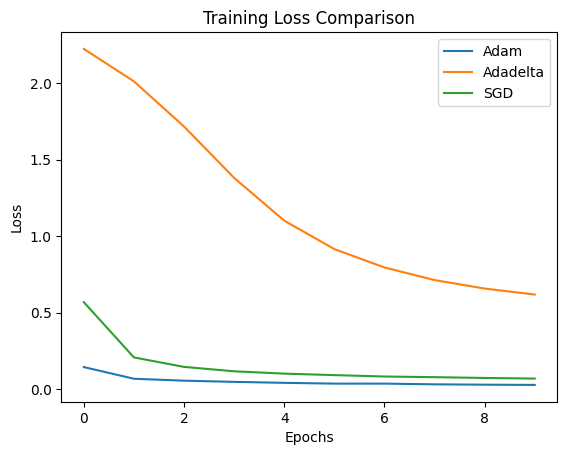

In [ ]:
#

plt.figure()

plt.plot(history_adam.history['loss'], label='Adam')
plt.plot(history_adadelta.history['loss'], label='Adadelta')
plt.plot(history_sgd.history['loss'], label='SGD')

plt.title('Training Loss Comparison')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

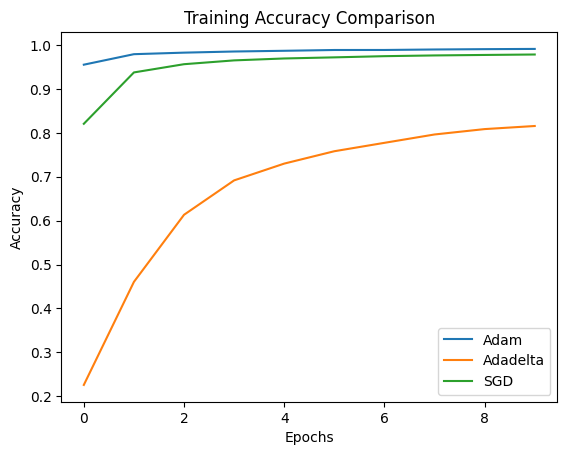

In [ ]:
#
plt.figure()

plt.plot(history_adam.history['accuracy'], label='Adam')
plt.plot(history_adadelta.history['accuracy'], label='Adadelta')
plt.plot(history_sgd.history['accuracy'], label='SGD')

plt.title('Training Accuracy Comparison')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

In [ ]:
def evaluate_model(optimizer_name):
    model = build_model()

    model.compile(
        optimizer=optimizer_name,
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    model.fit(x_train, y_train, epochs=10, verbose=0)

    loss, acc = model.evaluate(x_test, y_test)

    print(f"{optimizer_name} Test Accuracy:", acc)

In [ ]:
evaluate_model('adam')
evaluate_model('adadelta')
evaluate_model('sgd')

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9910 - loss: 0.0318
adam Test Accuracy: 0.9909999966621399
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8737 - loss: 0.4944
adadelta Test Accuracy: 0.8737000226974487
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9858 - loss: 0.0439
sgd Test Accuracy: 0.98580002784729


In [ ]:
predictions = model.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [ ]:
import numpy as np

predicted_labels = np.argmax(predictions, axis=1)
true_labels = np.argmax(y_test, axis=1)

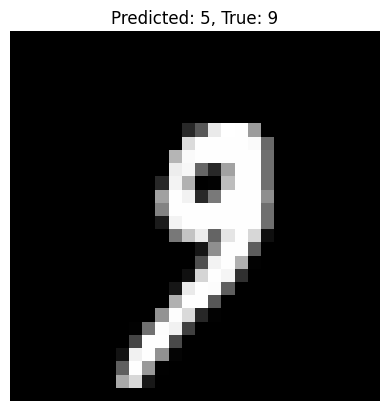

In [ ]:
index = 1000  # change this to test different images

plt.imshow(x_test[index].reshape(28,28), cmap='gray')
plt.title(f"Predicted: {predicted_labels[index]}, True: {true_labels[index]}")
plt.axis('off')
plt.show()

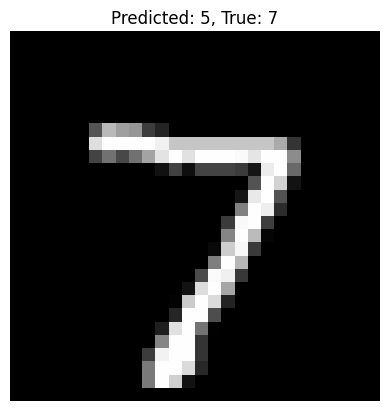

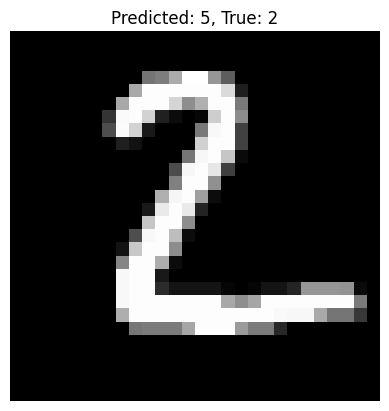

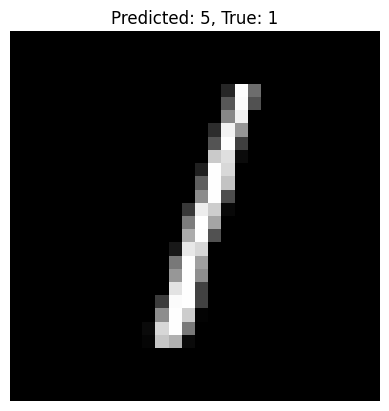

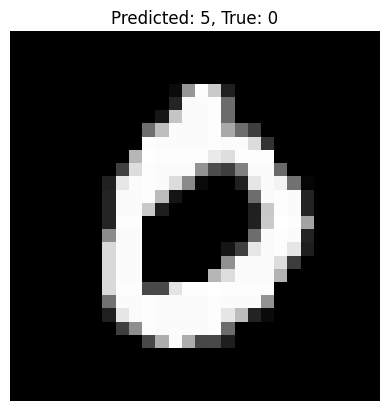

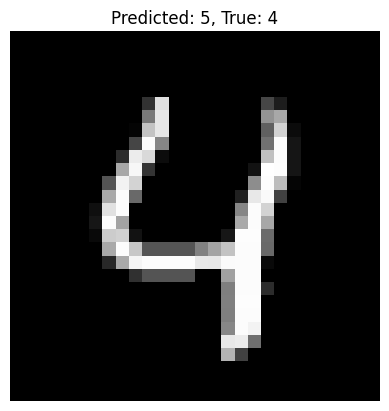

In [ ]:
for i in range(5):
    plt.imshow(x_test[i].reshape(28,28), cmap='gray')
    plt.title(f"Predicted: {predicted_labels[i]}, True: {true_labels[i]}")
    plt.axis('off')
    plt.show()

In [ ]:
correct = np.sum(predicted_labels == true_labels)
total = len(true_labels)

print("Manual Accuracy:", correct / total)

Manual Accuracy: 0.1061


Test Custom Image (ADVANCED & IMPRESSIVE)

If you draw a digit (e.g., “1”) and upload:

In [ ]:
from PIL import Image

img = Image.open('your_image.png').convert('L')
img = img.resize((28,28))

img = np.array(img) / 255.0
img = img.reshape(1,28,28,1)

prediction = model.predict(img)
print("Predicted digit:", np.argmax(prediction))

FileNotFoundError: [Errno 2] No such file or directory: 'your_image.png'

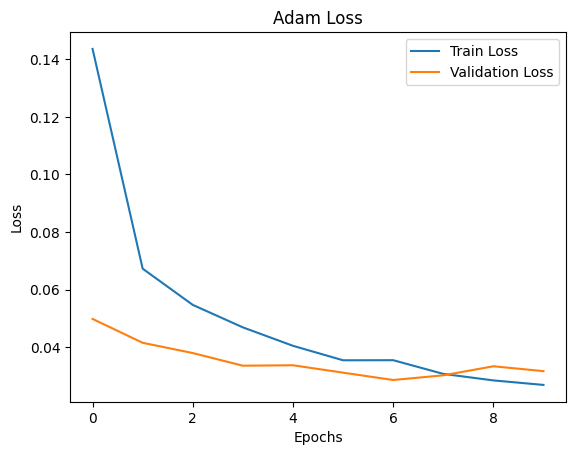

In [ ]:
plt.figure()

plt.plot(history_adam.history['loss'], label='Train Loss')
plt.plot(history_adam.history['val_loss'], label='Validation Loss')

plt.title('Adam Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

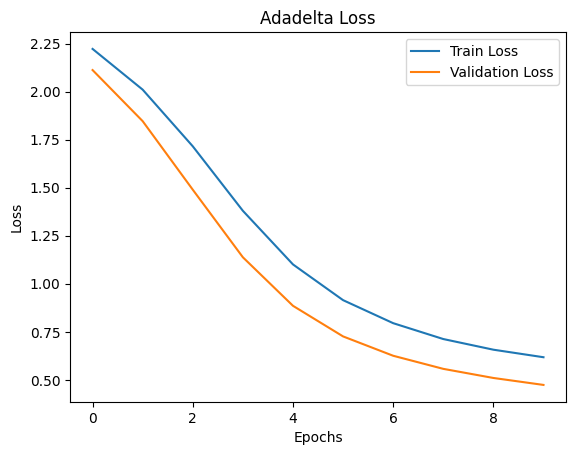

In [ ]:
plt.figure()

plt.plot(history_adadelta.history['loss'], label='Train Loss')
plt.plot(history_adadelta.history['val_loss'], label='Validation Loss')

plt.title('Adadelta Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

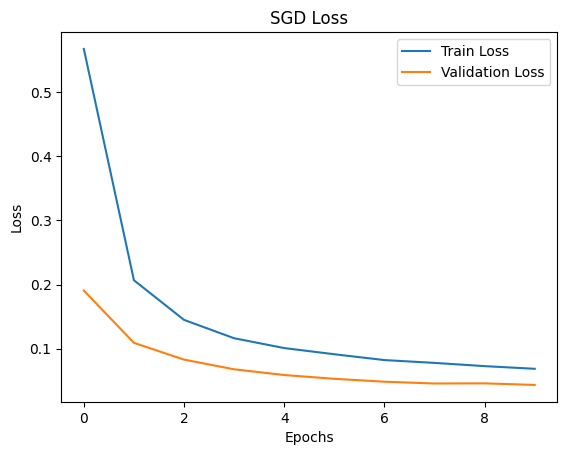

In [ ]:
plt.figure()

plt.plot(history_sgd.history['loss'], label='Train Loss')
plt.plot(history_sgd.history['val_loss'], label='Validation Loss')

plt.title('SGD Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

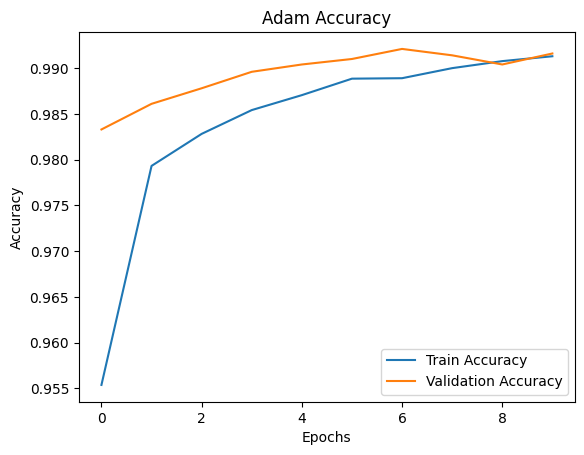

In [ ]:
plt.figure()

plt.plot(history_adam.history['accuracy'], label='Train Accuracy')
plt.plot(history_adam.history['val_accuracy'], label='Validation Accuracy')

plt.title('Adam Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

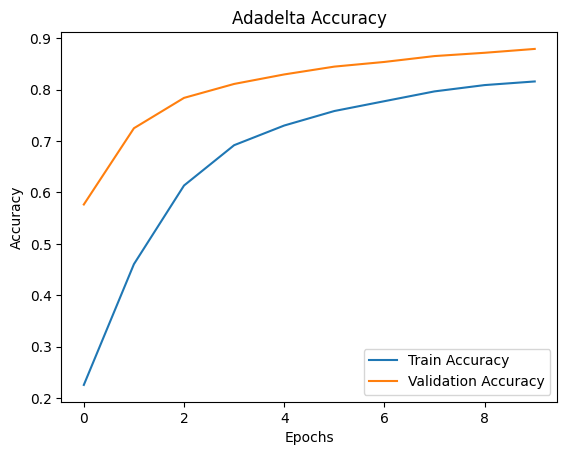

In [ ]:
plt.figure()

plt.plot(history_adadelta.history['accuracy'], label='Train Accuracy')
plt.plot(history_adadelta.history['val_accuracy'], label='Validation Accuracy')

plt.title('Adadelta Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

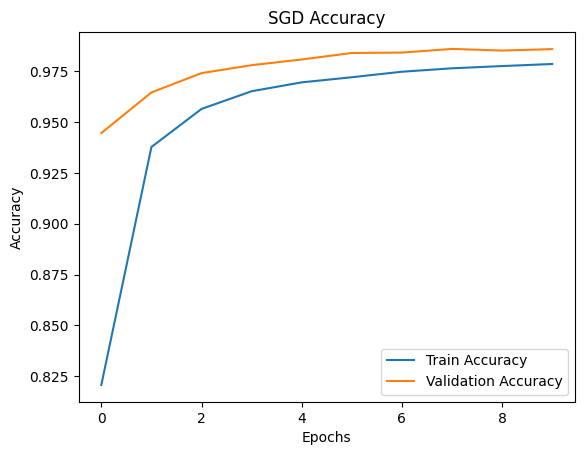

In [ ]:
plt.figure()

plt.plot(history_sgd.history['accuracy'], label='Train Accuracy')
plt.plot(history_sgd.history['val_accuracy'], label='Validation Accuracy')

plt.title('SGD Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

In [ ]:
#print('Python version:', platform.python_version())
print('Tensorflow version:', tf.__version__)
#print('Keras version:', tf.keras.__version__)

Tensorflow version: 2.19.0
